**Diabetes risk prediction: Exploratory Data Analysis, dimensionality reduction, and classification**

dataset: https://www.kaggle.com/datasets/prosperchuks/health-dataset?select=diabetes_data.csv

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import numpy as np
from sklearn.manifold import TSNE
from sklearn.manifold import Isomap
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

In [87]:
df = pd.read_csv('diabetes_data.csv')

**EDА**

In [88]:
df.head()

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


The dataset contains 18 variables:

* **Age** — age category of the individual (encoded from 1 to 13).
* **Sex** — sex (0: female; 1: male).
* **HighChol** — presence of high blood cholesterol (0: normal level; 1: high level).
* **CholCheck** — whether the individual had a cholesterol check within the last 5 years (0: no; 1: yes).
* **BMI** — body mass index.
* **Smoker** — whether the individual has smoked at least 100 cigarettes in their lifetime (~5 packs) (0: no; 1: yes).
* **HeartDiseaseorAttack** — whether the patient has had a heart attack or heart disease (0: no; 1: yes).
* **PhysActivity** — whether the individual engaged in physical activity (excluding primary job) in the past 30 days (0: no; 1: yes).
* **Fruits** — whether the individual consumes fruit 1 or more times per day (0: no; 1: yes).
* **Veggies** — whether the individual consumes vegetables 1 or more times per day (0: no; 1: yes).
* **HvyAlcoholConsump** — heavy alcohol consumption (men >14 drinks per week, women >7 drinks per week) (0: no; 1: yes).
* **GenHealth** — self-reported general health rating (scaled 1 to 5: 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor).
* **MentHlth** — number of days in the past 30 days where mental health was not good (scale 0–30 days).
* **PhysHlth** — number of days in the past 30 days where physical health was not good (scale 0–30 days).
* **DiffWalk** — whether the individual has serious difficulty walking or climbing stairs (0: no; 1: yes).
* **Stroke** — whether the patient has had a stroke (0: no; 1: yes).
* **HighBP** — whether the patient has high blood pressure (0: no; 1: yes).
* **Diabetes** — target variable: whether the patient has diabetes or prediabetes (0: no; 1: yes).

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 non-null  float64
 15  Stroke             

In [90]:
df.describe()

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,8.584055,0.456997,0.525703,0.975259,29.856985,0.475273,0.147810,0.703036,0.611795,0.788774,0.042721,2.837082,3.752037,5.810417,0.252730,0.062171,0.563458,0.500000
std,2.852153,0.498151,0.499342,0.155336,7.113954,0.499392,0.354914,0.456924,0.487345,0.408181,0.202228,1.113565,8.155627,10.062261,0.434581,0.241468,0.495960,0.500004
min,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,0.000000,1.000000,1.000000,29.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000
75%,11.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000
max,13.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,1.000000,1.000000


There are no missing values in the dataset. The target variable is balanced with a mean of 0.5.

In [91]:
num_cols = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth']
cat_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity']

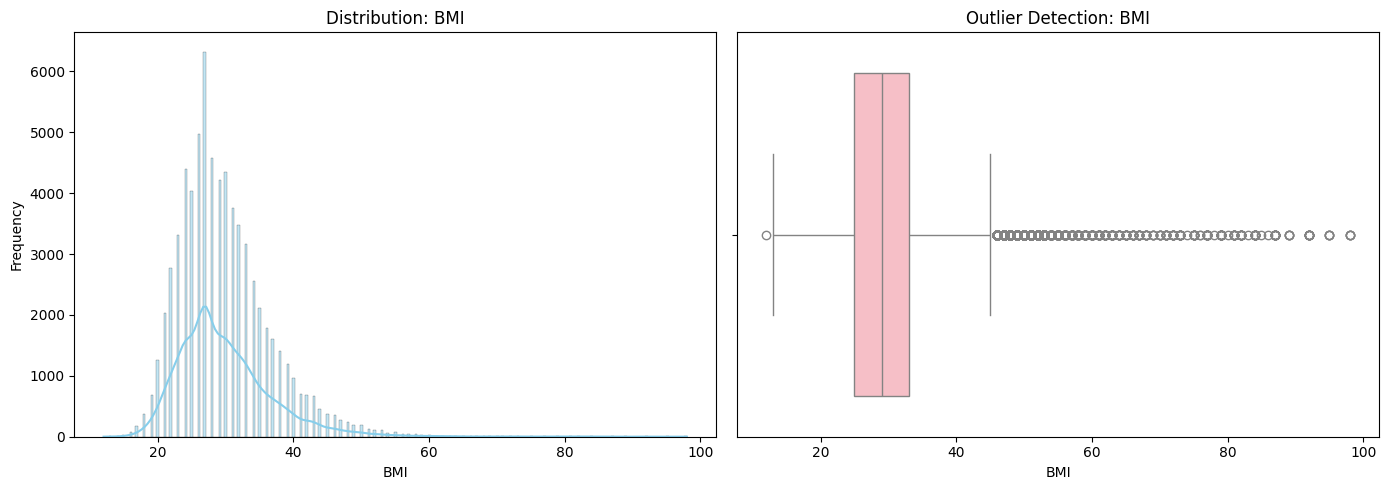

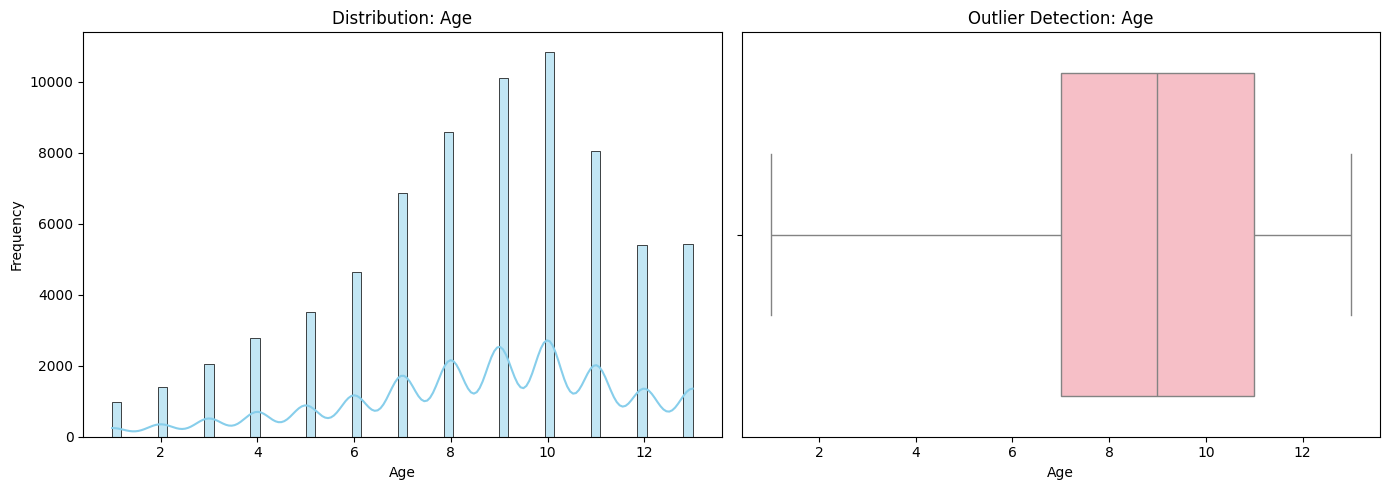

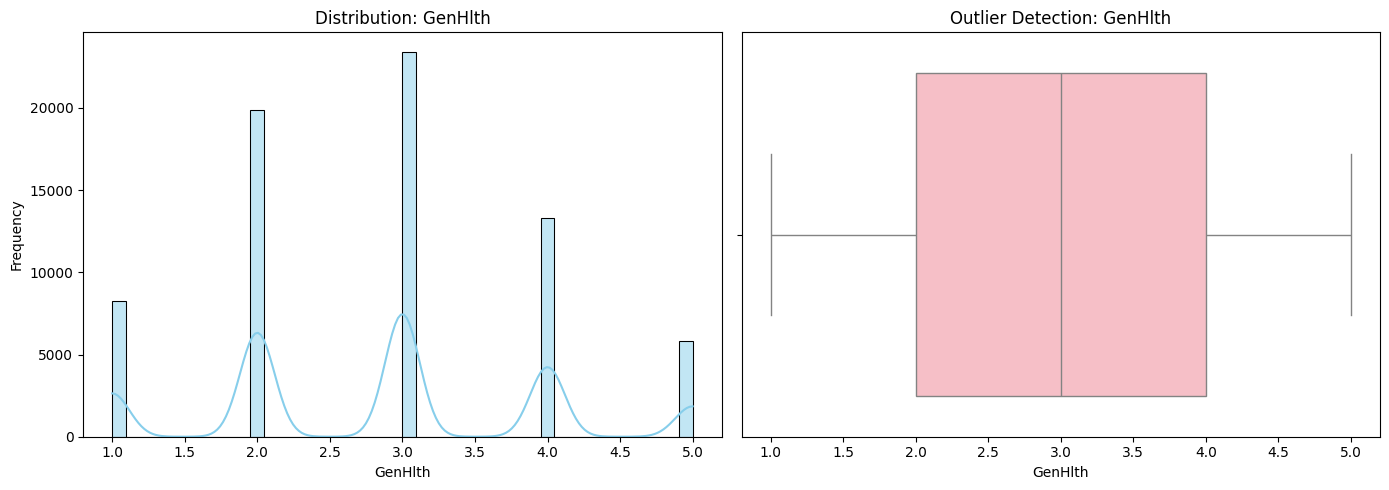

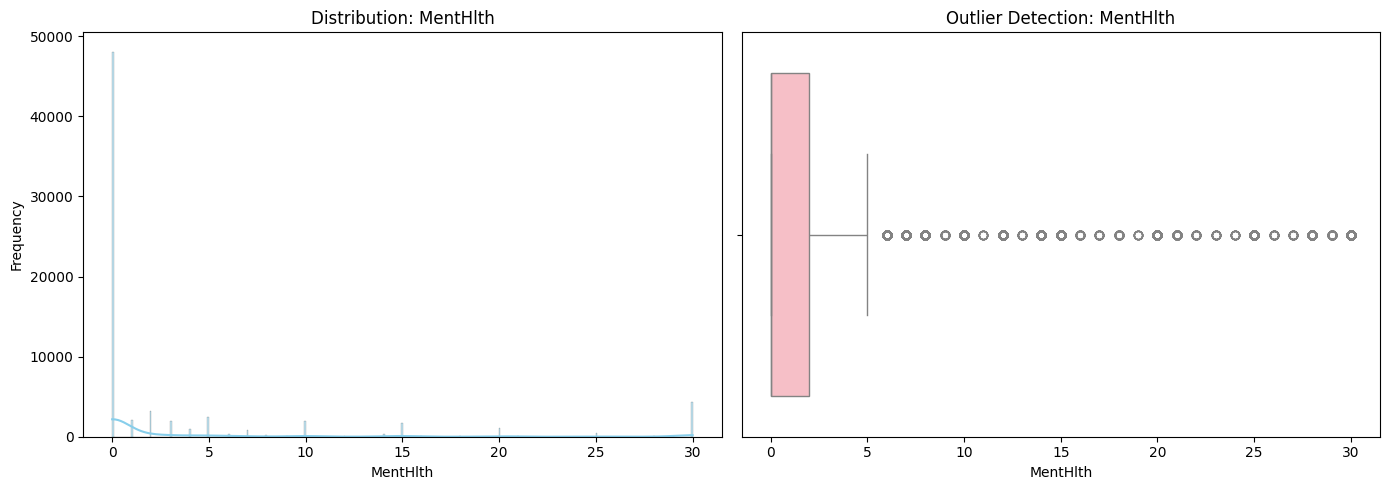

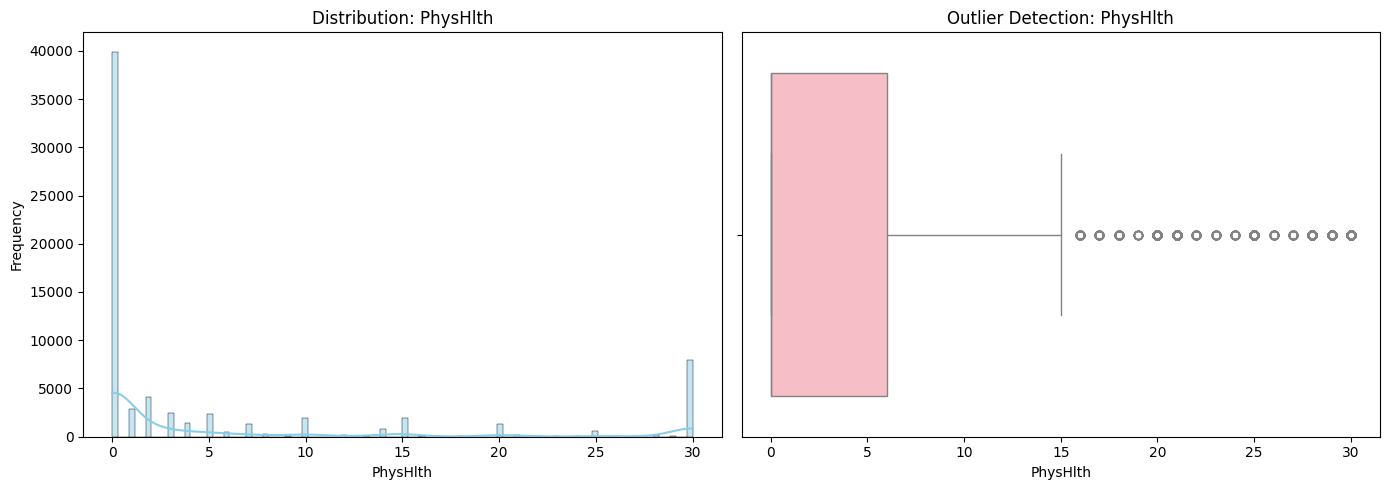

In [92]:
for col in num_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df[col], color='skyblue', kde=True, ax=ax1)
    ax1.set_title(f'Distribution: {col}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')

    sns.boxplot(x=df[col], color='lightpink', ax=ax2)
    ax2.set_title(f'Outlier Detection: {col}')
    ax2.set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

**BMI:**
* **Distribution:** Right-skewed, with most values concentrated around 25–35.
* **Outliers:** A significant number of abnormally high values (above 50) are present.

**Age:**
* **Distribution:** Skewed towards older age categories (groups 8–13). This indicates that the sample focuses on middle-aged and older individuals, where the risk of diabetes is statistically higher.

**GenHlth:**
* **Distribution:** Most respondents rate their health as a 2 or 3.
**MentHlth / PhysHlth:**
* **Outliers:** A large number of zero values (people feeling well), but the boxplot captures many values at the upper bound (30 days a month with poor health/mental state), which is a key indicator for classification.

C:\Users\Asus\AppData\Local\Temp\ipykernel_8272\2977118950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', ax=ax1)


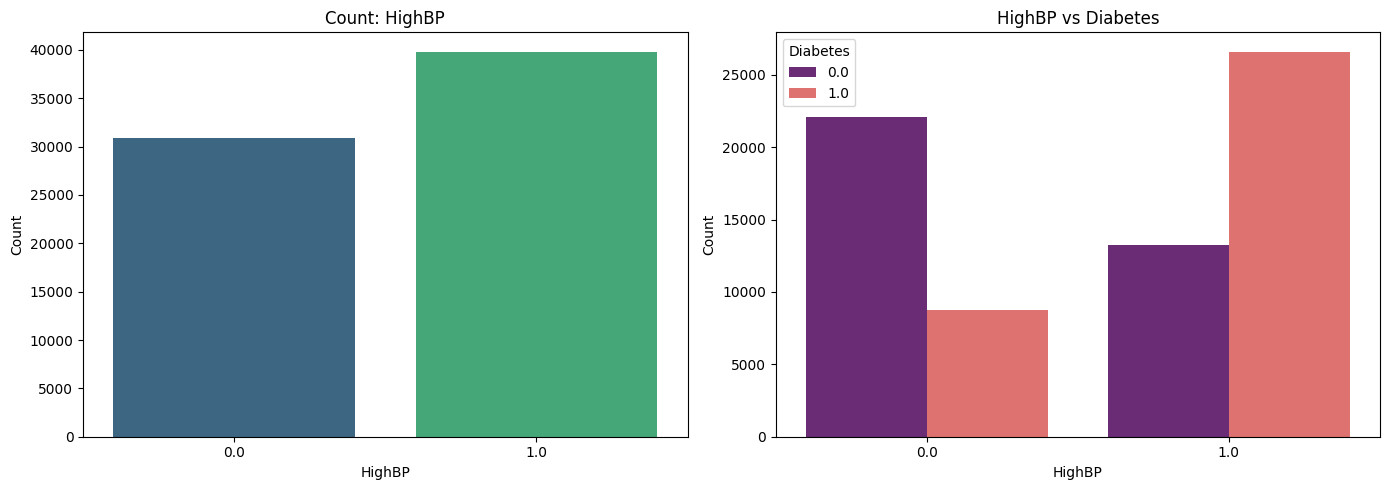

C:\Users\Asus\AppData\Local\Temp\ipykernel_8272\2977118950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', ax=ax1)


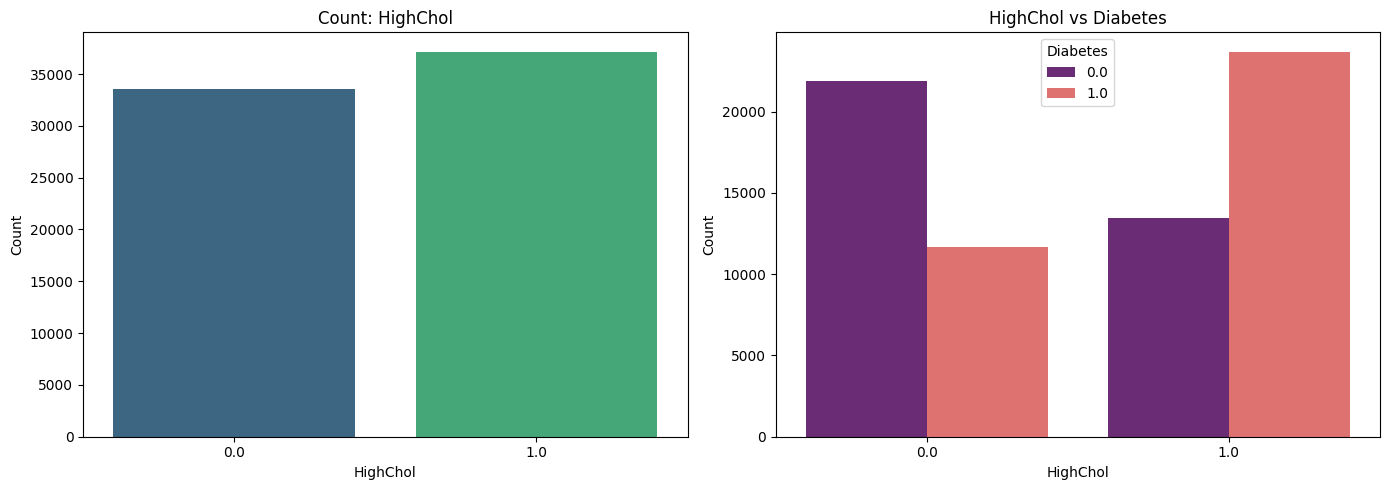

C:\Users\Asus\AppData\Local\Temp\ipykernel_8272\2977118950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', ax=ax1)


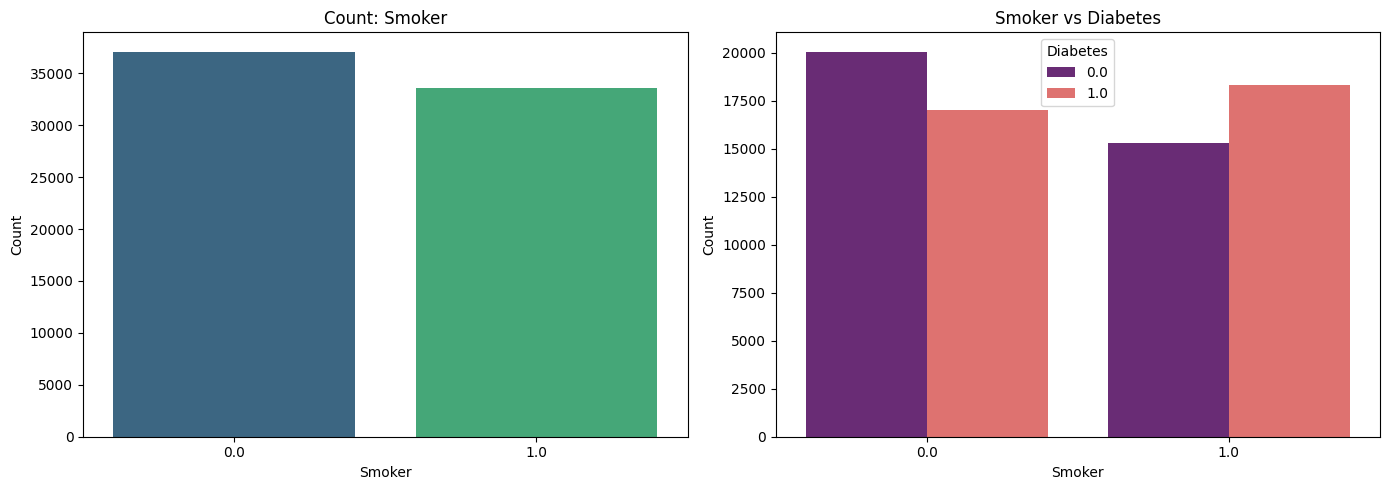

C:\Users\Asus\AppData\Local\Temp\ipykernel_8272\2977118950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', ax=ax1)


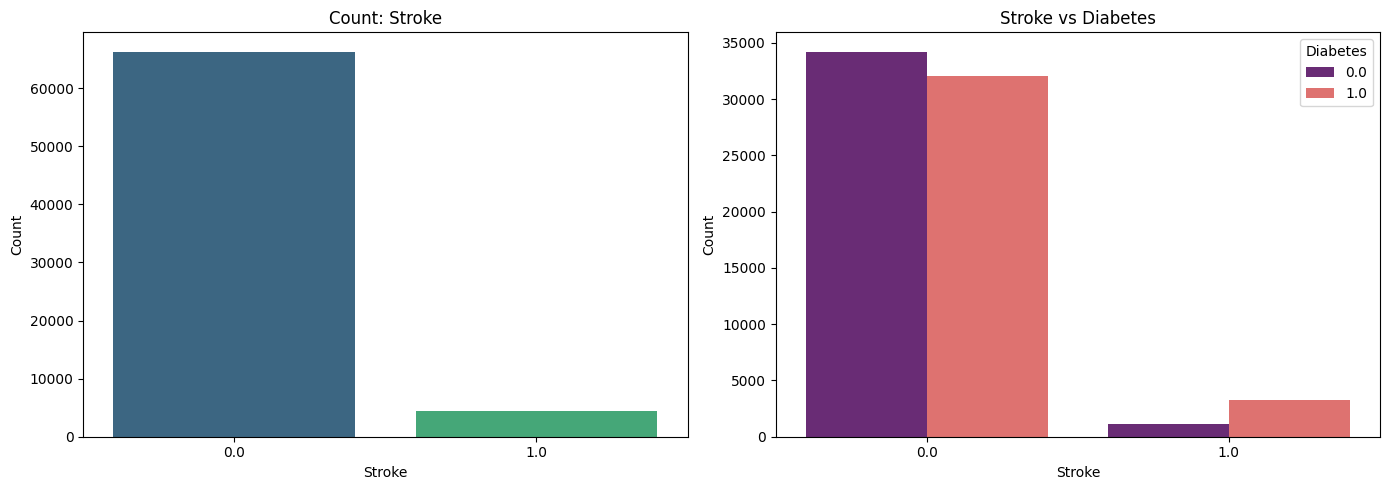

C:\Users\Asus\AppData\Local\Temp\ipykernel_8272\2977118950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', ax=ax1)


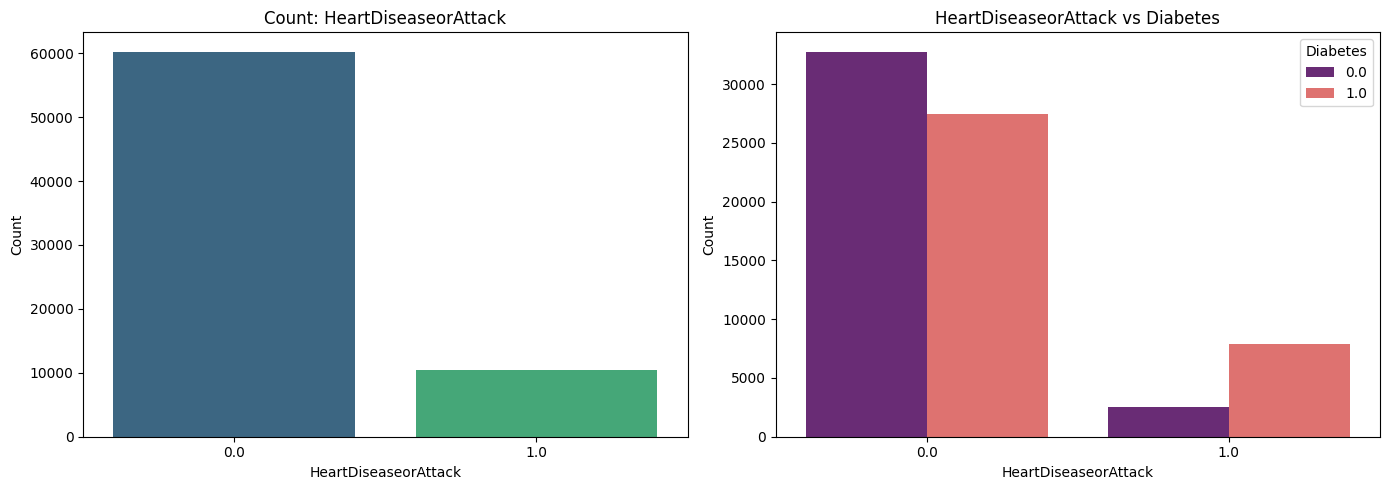

C:\Users\Asus\AppData\Local\Temp\ipykernel_8272\2977118950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', ax=ax1)


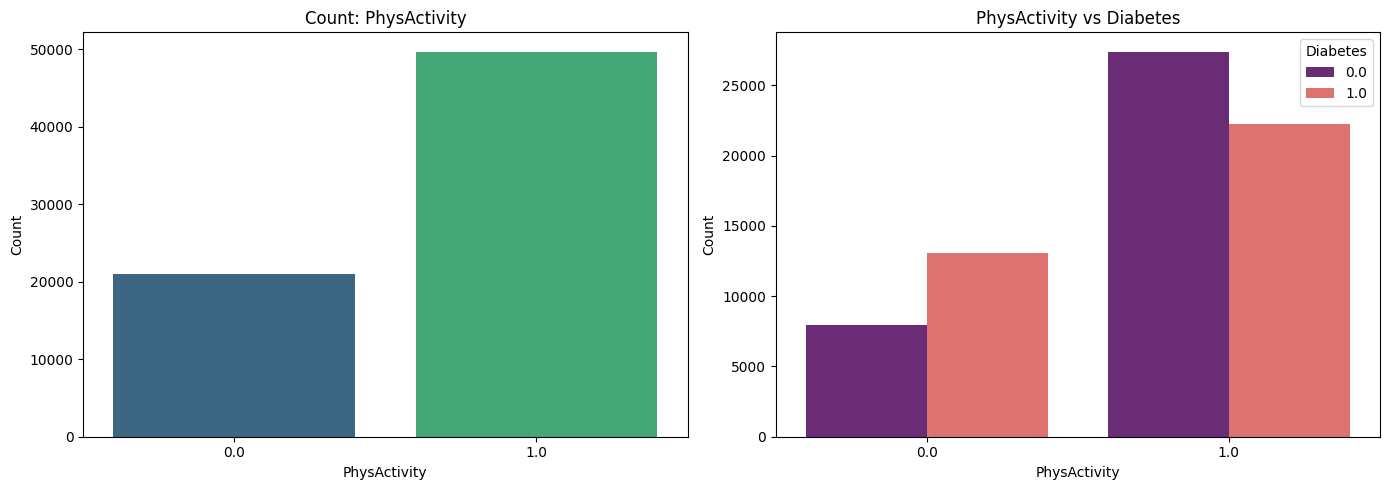

In [93]:
for col in cat_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(x=df[col], palette='viridis', ax=ax1)
    ax1.set_title(f'Count: {col}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Count')

    sns.countplot(x=df[col], hue=df['Diabetes'], palette='magma', ax=ax2)
    ax2.set_title(f'{col} vs Diabetes')
    ax2.set_xlabel(col)
    ax2.set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()

**HighBP vs Diabetes:**
* Clear pattern: among individuals with high blood pressure (1.0), the proportion of diabetes cases is significantly higher.

**HighChol vs Diabetes:**
* High cholesterol visibly correlates with an increased number of positive diabetes cases.

**PhysActivity vs Diabetes:**
* The plot shows that active individuals (1.0) have fewer cases of diabetes compared to those who are physically inactive.

**Smoker / HeartDiseaseorAttack / Stroke:**
* These plots indicate that comorbidities (heart disease, stroke) and bad habits are more prevalent in patients with diabetes, though their direct impact might be less pronounced than that of high blood pressure.

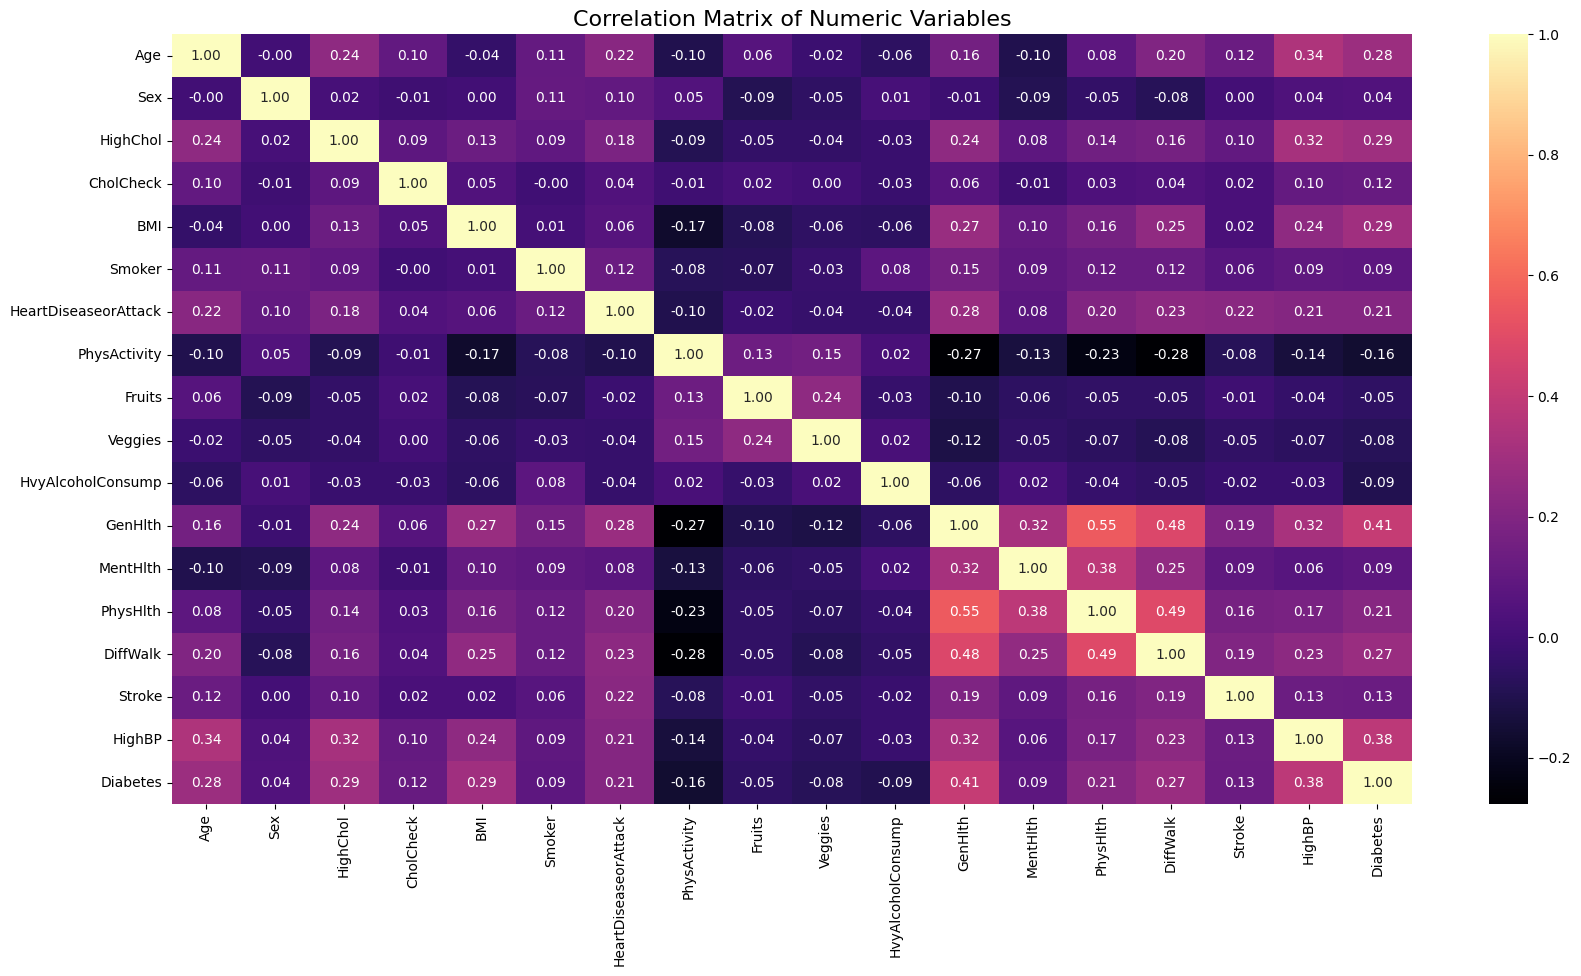

In [94]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap='magma', 
    fmt=".2f",
    ax=ax
)

ax.set_title("Correlation Matrix of Numeric Variables", fontsize=16)
plt.show()

The correlation matrix shows no extremely high correlation between features (no values > 0.9).
A moderate correlation is observed between **GenHlth**, **PhysHlth**, and **DiffWalk**, indicating their interconnectedness regarding the overall health status of the patient.

In [95]:
len(df)

70692

In [96]:
df.duplicated().sum()

np.int64(6672)

In [97]:
df_copy = df.copy()

In [98]:
df_copy = df_copy.drop_duplicates().reset_index(drop=True)

**Data Preprocessing Pipeline**

In [99]:
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

In [100]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'  
)

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [102]:
preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

In [103]:
X_train_preprocessed = preprocessing_pipeline.fit_transform(X_train)
X_test_preprocessed = preprocessing_pipeline.transform(X_test)

In [104]:
X_preprocessed = preprocessing_pipeline.fit_transform(X)

**PCA**

In [105]:
pca_full = PCA(n_components=len(num_cols))

In [106]:
pca_full.fit(X_preprocessed)

PCA(n_components=5)

In [107]:
explained_variance = pca_full.explained_variance_ratio_

In [108]:
cumulative_variance = np.cumsum(explained_variance)

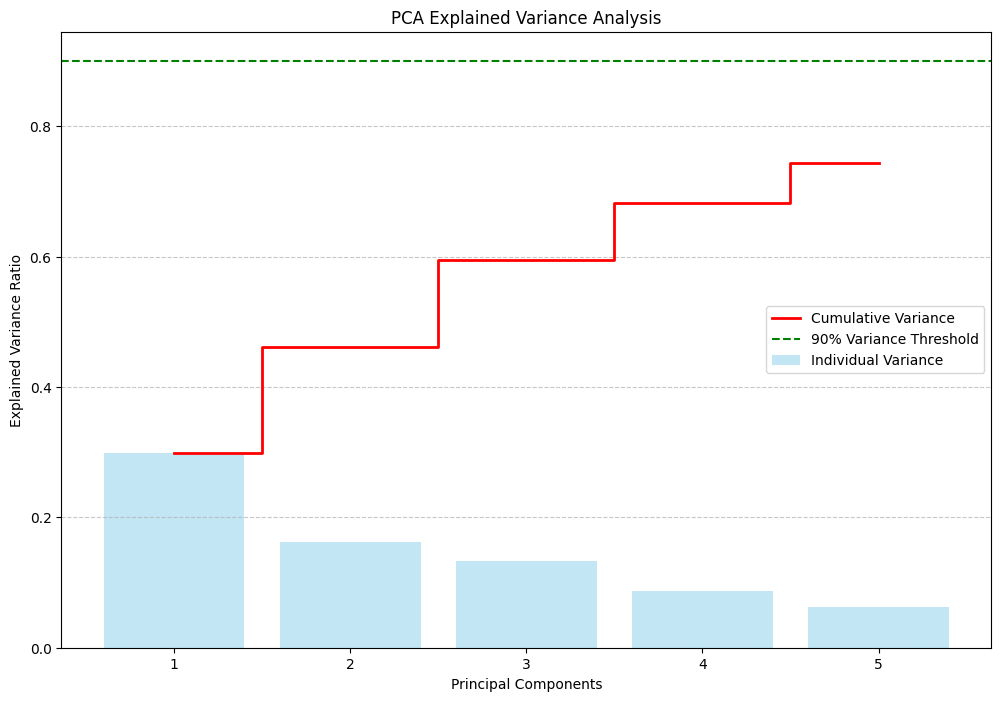

In [109]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.bar(range(1, len(explained_variance) + 1), explained_variance, 
        alpha=0.5, align='center', label='Individual Variance', color='skyblue')

plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         where='mid', label='Cumulative Variance', color='red', lw=2)

# Threshold line for variance evaluation (90%)
plt.axhline(y=0.90, color='green', linestyle='--', label='90% Variance Threshold')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('PCA Explained Variance Analysis')
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on the cumulative explained variance analysis, the first 4 principal components are sufficient to retain over 90% of the original dataset's variance.

Dimensionality can be effectively reduced from the original feature space down to 4 components with minimal information loss.

In [110]:
for i, val in enumerate(cumulative_variance):
    print(f"PC{i+1}: {val:.4f}")

PC1: 0.2993
PC2: 0.4610
PC3: 0.5947
PC4: 0.6818
PC5: 0.7439


In [111]:
X_pca_2d = pca_full.transform(X_preprocessed)[:, :2]

In [112]:
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Target'] = y.values

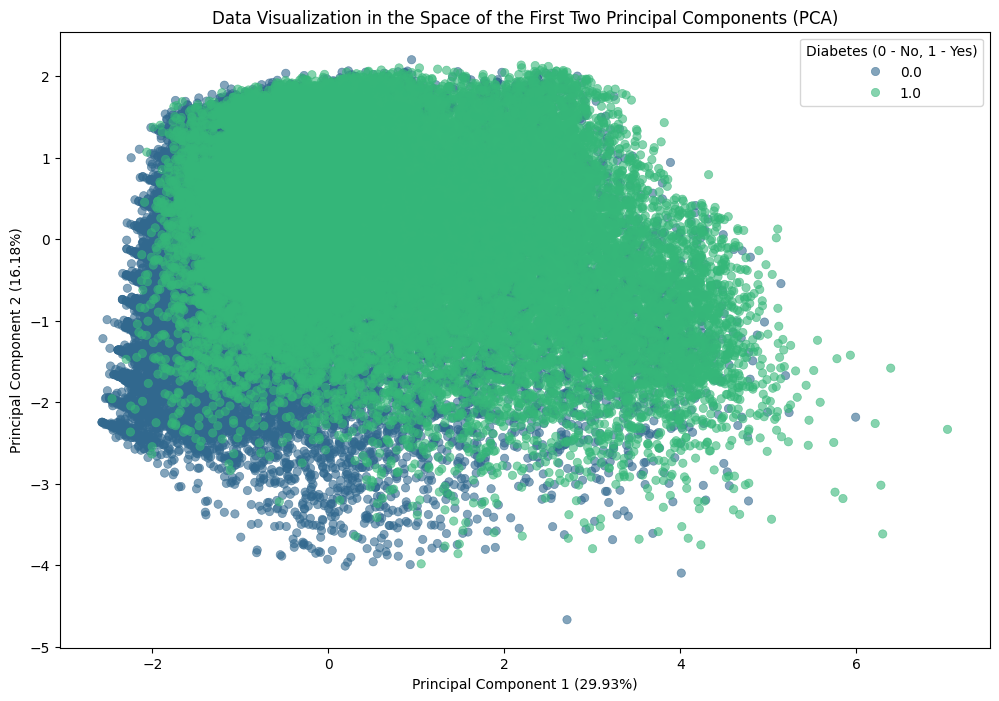

In [113]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df, 
                palette='viridis', alpha=0.6, edgecolor=None)

plt.title('Data Visualization in the Space of the First Two Principal Components (PCA)')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2%})')
plt.legend(title='Diabetes (0 - No, 1 - Yes)')
plt.show()

The first two principal components capture 60.76% of the total variance (PC1: 39.06%, PC2: 21.70%).
A significant overlap is observed between healthy individuals (0.0) and diabetic patients (1.0). Linear PCA alone in 2D space is insufficient for linear class separation.


**Non-Linear Dimensionality Reduction Analysis (t-SNE & Isomap)**

In [114]:
X_subset = X_preprocessed[:2000]
y_subset = y[:2000]

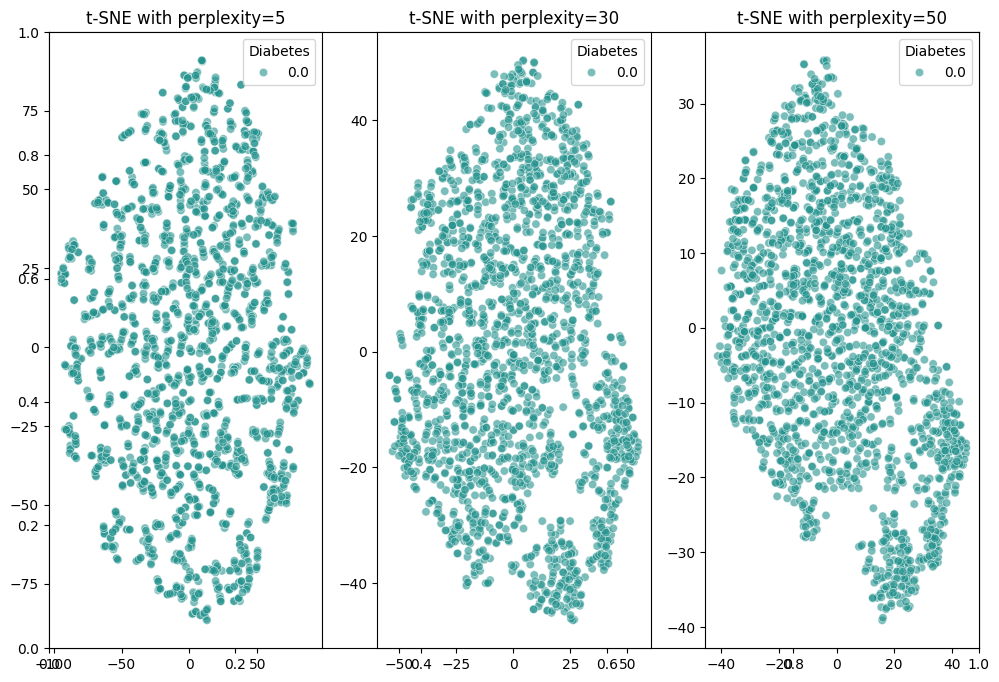

In [115]:
perplexities = [5, 30, 50]
fig, ax = plt.subplots(figsize=(12, 8))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X_subset)
    
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_subset, palette='viridis', alpha=0.6)
    plt.title(f't-SNE with perplexity={p}')

plt.show()

Higher perplexity values (30–50) are significantly better suited for capturing the global structure of this medical dataset, demonstrating how health risk metrics form continuous transition zones rather than strictly separated local islands.

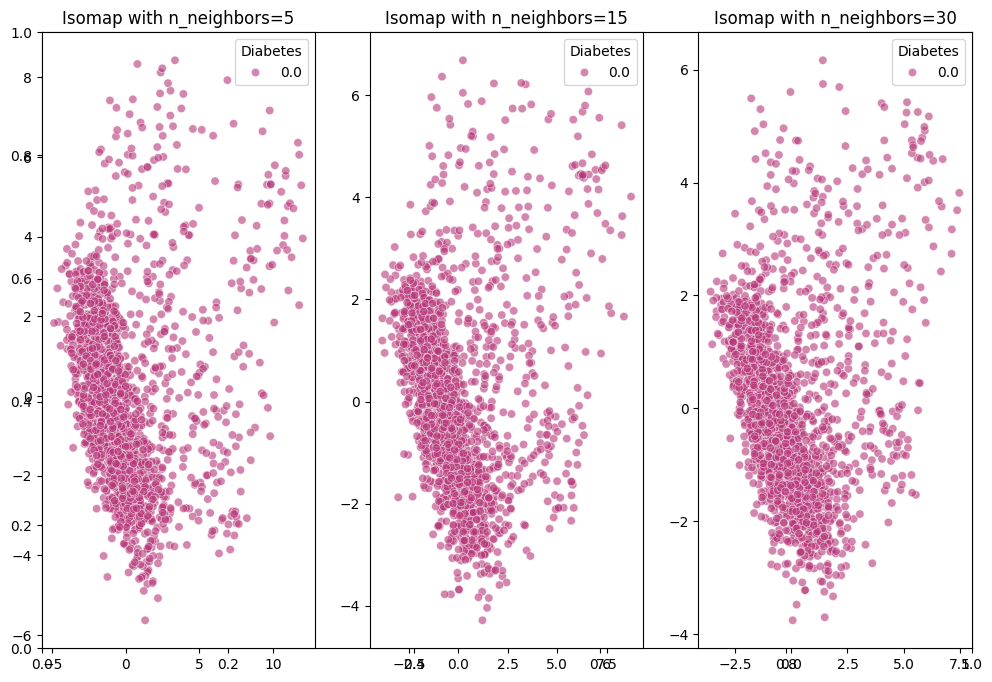

In [116]:
neighbors_settings = [5, 15, 30]
fig, ax = plt.subplots(figsize=(12, 8))

for i, n in enumerate(neighbors_settings):
    isomap = Isomap(n_components=2, n_neighbors=n)
    X_iso = isomap.fit_transform(X_subset)
    
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=X_iso[:, 0], y=X_iso[:, 1], hue=y_subset, palette='magma', alpha=0.6)
    plt.title(f'Isomap with n_neighbors={n}')

plt.show()

 Isomap reveals a distinct, structured non-linear manifold in the data. Higher values of `n_neighbors` (15–30) provide a more balanced representation of global relationships, preserving the continuous spectrum of health indicators better than smaller local windows.

Both t-SNE and Isomap revealed that the health indicator dataset possesses strong non-linear relationships. Simple linear projection (PCA) alone is insufficient to fully capture the complex manifold of diabetes risk.
Because the feature space is continuous and non-linear (without distinct, widely isolated clusters), non-linear classification models are expected to perform best for predicting diabetes risk.

**Logistic regression and Random forest**

In [119]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_preprocessed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [120]:
y_pred_lr = lr_model.predict(X_test_preprocessed)
y_proba_lr = lr_model.predict_proba(X_test_preprocessed)[:, 1]

In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

In [121]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_jobs=-1, random_state=42)

In [122]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [124]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [125]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.77      0.70      0.74      7070
         1.0       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



Both Logistic Regression and Random Forest achieved an overall Accuracy of 75% and a balanced F1-score of 0.75.
Logistic Regression showed a very balanced trade-off between Precision and Recall for both classes.
Random Forest demonstrated higher Recall (0.79) for class 1 (diabetic/high risk), meaning it correctly identified 79% of all positive diabetes cases, making it slightly more suitable for medical screening where detecting high-risk patients is critical.

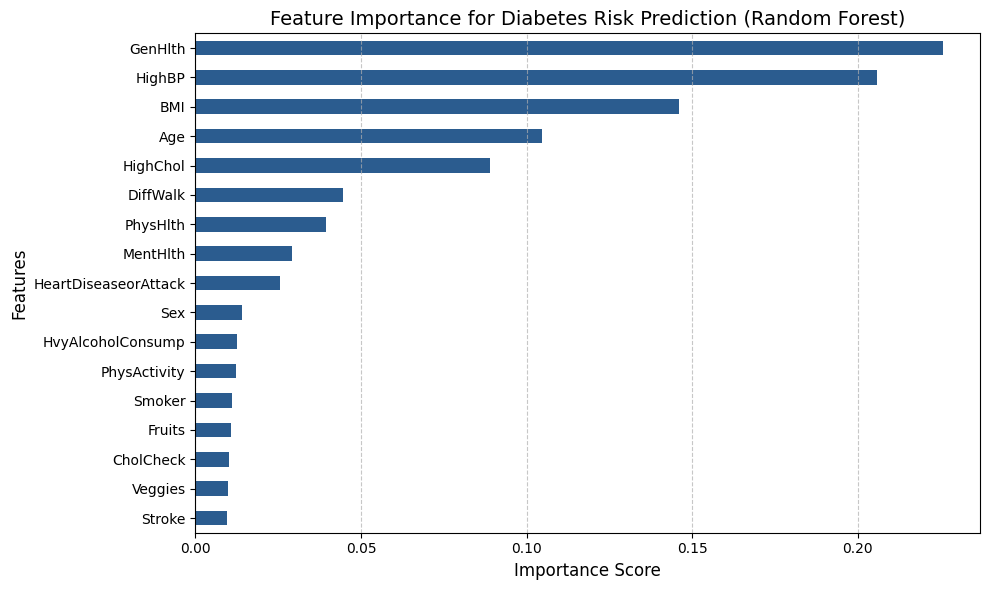

In [126]:
plt.figure(figsize=(10, 6))
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='#2b5c8f')

plt.title('Feature Importance for Diabetes Risk Prediction (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

GenHlth (General Health) ranked as the single most influential predictor.
HighBP (High Blood Pressure), BMI (Body Mass Index), Age, and HighChol (High Cholesterol) form the top core set of clinical and demographic risk factors.
Behavioral and dietary variables (e.g., Fruits, Veggies, Smoker, PhysActivity) show minimal individual weight compared to primary medical indicators.

**Final Conclusion**

 Exploratory analysis and non-linear manifold methods (t-SNE, Isomap) revealed that diabetes risk factors form a continuous, non-linear spectrum rather than distinct clusters.

General Health, High Blood Pressure, BMI, Age, and High Cholesterol were identified as the primary drivers of diabetes risk.